
  <img src="https://github.com/gefero/factor_data_SICSS_Baires_2026/blob/main/imgs/logo_final_conjunto.png?raw=true" width="80%">


# Summer Institute in Computational Social Sciences - Buenos Aires 2026
# Taller: Procesamiento de Lenguaje Natural y polarización
# LLMs y uso de APIs

### Profesor: Germán Rosati


## Introducción
Este notebook ofrece una introducción a los Large Language Models (LLMs), centrándose en el modelo Gemini desarrollado por Google. Se exploran los conceptos básicos de los transformers, el mecanismo de self-attention, el prompt engineering y estrategias para interactuar con un LLM.

Como caso de aplicación, retomamos el dataset **HatEval** (SemEval-2019 Task 5) que venimos usando en las clases anteriores, y en particular su *test set* (`data/hateval_test_df.csv`), para clasificar tweets en español según si contienen o no discurso de odio (`HS`) utilizando Gemini. Se analizan los resultados y se realiza un análisis de errores para identificar las limitaciones del modelo.

El objetivo principal es comprender cómo funcionan los LLMs, sus potencialidades y cómo aplicarlos a tareas de procesamiento de lenguaje natural.

Pero antes tenemos que introducir una última cuestión. ¿Cómo interactuamos con un LLM?

## Cómo usar un LLM y qué es el prompt engineering
Ya mencionamos que un LLM es una herramienta sumamente útil que permite realizar diversas tareas basadas en texto: desde resúmenes y clasificaciones hasta generación de contenido y análisis de sentimientos. Sin embargo, su eficacia depende de cómo interactuemos con él. Aquí entra en juego el concepto de **prompt engineering**. Es la tarea que consiste en diseñar instrucciones claras y efectivas para maximizar la calidad de las respuestas del modelo.

Un LLM, como Gemini, está entrenado en vastos conjuntos de datos para reconocer patrones en el lenguaje. Aunque no "piensa" como un humano, puede generar respuestas coherentes y contextuales basadas en entradas específicas. El modelo procesa instrucciones llamadas *prompts*, que son preguntas, textos o comandos diseñados para guiar su comportamiento.

Por ejemplo, si queremos traducir una frase:
- Mal prompt: *"Traducción al inglés."*
- Buen prompt: *"Traduce la frase 'El perro juega en el parque' al inglés."*

Un buen prompt debe ser claro, estructurado y, cuando sea necesario, incluir ejemplos o contexto. Para usar en LLM tenemos que seguir algunos pasos:

1. **Definir la tarea**: Antes de usar un LLM, aclarar qué se busca lograr: ¿Resumir? ¿Clasificar? ¿Analizar sentimientos? Esto determinará cómo diseñar el prompt.

2. **Diseñar el prompt**: Asegurarse de que la instrucción:
   - Sea específica.
   - Proporcione contexto relevante.
   - Indique el formato esperado de la respuesta.

3. **Usar la herramienta adecuada**:
   - *Interfaz directa*: Plataformas como Gemini permiten interactuar con el modelo escribiendo prompts directamente.
   - *API programática*: Si es necesario integrar el LLM en proyectos, es poisble usar lenguajes como Python o R para enviar solicitudes al modelo.

4. **Revisar e iterar**: Evaluar las respuestas y ajustar el prompt según sea necesario. La iteración es clave para obtener resultados óptimos.

### Estrategias de prompt engineering
Hay varias formas de diseñar un prompt.

1. **Zero-shot prompting**
Pide al modelo realizar una tarea sin ningún ejemplo previo. Es útil para tareas simples. Por ejemplo,
```
Traduce al inglés: 'El perro juega en el parque
```

2. **One-shot prompting**
Proporciona un ejemplo para guiar al modelo.
 ```
 Genera una pregunta para una encuesta sobre satisfacción laboral.
 Ejemplo: '¿Qué tan satisfecho está con su horario de trabajo?'
 Nueva pregunta:
 ```

3. **Few-shot prompting**
Incluye varios ejemplos para ayudar al modelo a generalizar mejor.
```
Clasifica las siguientes frases según la emoción:
- "Estoy feliz hoy." → Alegría
- "Estoy cansado." → Tristeza
- "Estoy ansioso por mañana." → Ansiedad

Frase: "No puedo creer que gané la lotería." → Emoción:
 ```

4. **Chain-of-thought prompting**
Solicita que el modelo muestre su razonamiento paso a paso antes de dar una respuesta final.
```
Pregunta: Si Juan tiene 3 manzanas y compra 5 más, ¿cuántas tiene en total? Razonamiento:

1. Juan tiene 3 manzanas.
2. Compra 5 más, así que ahora tiene 3 + 5.

Respuesta final:
```

5. **Contextual prompting**
Proporciona al modelo un contexto para que las respuestas sean más relevantes.
```
 Eres un experto en marketing. Crea un eslogan para una marca de café sostenible.
```

6. **Instruction-based prompting**
Diseña el prompt como una instrucción directa y detallada.
```
Resume el siguiente texto en tres frases que incluyan las ideas principales: [texto].
```

Pese a lo bien que funcionan los LLMs es necesario tener en cuenta algunas limitaciones a los fines de evitar malos entendidos.

En primer lugar, más allá del marketing alrededor de estas herramientas es importante mencionar que **no razonan como humanos**. Se limitan a generar respuestas basadas en patrones estadísticos, de allí el término ["loros aleatorios"](https://dl.acm.org/doi/10.1145/3442188.3445922). ¿Esto es un problema? Depende. Si los queremos usar para resolver tareas concretas como las que hemos mencionado hasta aquí como la que vamos a atacar en breve, no. En otros contextos, puede ser.

A su vez, los LLMS (al igual que cualquier otro algoritmo, modelo o método que se basa en datos de entrada y trata de aprender patrones subyacentes) tienen **sesgos**. Hay una amplísima bibliografía  Pueden reflejar sesgos presentes en los datos de entrenamiento. Esto hace que sea necesario tener cuidado al momento de seleccionar la tarea que vamos a solicitarle. Por otro lado, tienen **memoria limitada**, no recuerdan interacciones previas a menos que se incluyan en el contexto.

# Gemini, el modelo que vamos a usar
Google DeepMind ha desarrollado Gemini, una familia de modelos de inteligencia artificial con capacidades multimodales. Esto implica que Gemini puede procesar y comprender diversos tipos de información, como texto e imágenes.

![](../imgs/logo.jpeg)

Gemini es un modelo de lenguaje grande (LLM) que utiliza una arquitectura de red neuronal Transformer. Esta arquitectura le permite procesar información de manera eficiente y comprender las relaciones entre las palabras en un texto.

Gemini fue entrenado por Google utilizando una gran cantidad de datos de texto y código. Este proceso de entrenamiento implica ajustar los parámetros de la red neuronal para que pueda predecir la siguiente palabra o token en una secuencia. El entrenamiento se realiza en varias etapas, con conjuntos de datos cada vez más grandes y complejos. Esto permite a Gemini aprender patrones y relaciones en el lenguaje, mejorando su capacidad para comprender y generar texto.

# El caso de aplicación
Vamos a volver sobre el dataset **HatEval** que venimos usando en las clases anteriores y a retomar la tarea de clasificar tweets según si contienen discurso de odio (`HS=1`) o no (`HS=0`). Vamos a trabajar sobre el mismo *test set* en español que usamos para evaluar TF, TF-IDF y embeddings (`data/hateval_test_df.csv`), pero sobre una muestra estratificada de unos 200 tweets, dado que la API de Gemini (y `google.colab.ai`) solamente permite un número limitado de requests gratis en un día.

Primero vamos a instalar la librería que nos va a servir de interface para trabajar con Gemini. La misma la pueden encontrar en https://github.com/google-gemini/generative-ai-python. Es la librería oficial de Google para interactuar con la API de Gemini en Python. Ejecutando la celda siguiente pueden instalar el paquere.

In [ ]:
!pip install google-generativeai
!apt-get -qq install -y git-lfs >/dev/null && git lfs install --skip-repo
!git clone https://github.com/gefero/factor_data_SICSS_Baires_2026.git


Cloning into 'factor_data_SICSS_Baires_2026'...
remote: Enumerating objects: 192, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 192 (delta 102), reused 122 (delta 49), pack-reused 15 (from 1)
Receiving objects: 100% (192/192), 147.13 MiB | 29.72 MiB/s, done.
Resolving deltas: 100% (104/104), done.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_fscore_support
)
import re
import time
import unicodedata
#import google.generativeai as genai


## Primer paso, autenticación
Como ya hemos visto a lo largo de este curso, las APIs actúan como intermediarios que permiten la comunicación e intercambio de datos entre diferentes sistemas. Por este motivo, la autenticación es crucial para asegurar la seguridad y controlar el acceso a la información.

Para usar `google-generativeai`, debemos autenticarnos con una clave personal que debemos crear en https://aistudio.google.com/app/apikey. La función `genai.configure` en `google-generativeai` nos permite configurar esta clave.

Por algún motivo, estos días la API de Gemini está muy restrictiva para los usuarios gratis, por eso vamos a usar [una librería bastante útil](https://medium.com/google-colab/introducing-google-colab-ai-the-easiest-way-to-use-generative-ai-in-colab-no-setup-required-eee01230e0cf) que tiene Colab y que, por ahora, es gratis:

In [ ]:
from google.colab import ai
#response = ai.generate_text("What is the capital of France?")
#print(response)

In [ ]:
ai.list_models()

['google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemini-3.1-pro-preview',
 'google/gemini-3.5-flash']

## Segundo paso, diseño del prompt
Perfecto. Vamos ahora a diseñar un prompt simple para nuestra tarea.

In [ ]:
prompt = """A continuación vas a recibir el texto de un tweet.
Quisiera que lo clasifiques como discurso de odio o no usando las siguientes categorías:

- Odio: el tweet expresa odio dirigido a mujeres o a inmigrantes **como grupo** (por ejemplo, insultos, deshumanización o llamados a la violencia contra esos colectivos)
- No odio: el tweet no expresa ese tipo de odio grupal. Esto incluye insultos puntuales a una persona, lenguaje ofensivo usado como intensificador (p. ej. interjecciones), o menciones/citas de discurso de odio ajeno sin que el propio tweet lo exprese

Quisiera que expliques paso a paso tu razonamiento.

La salida debería tener el siguiente formato:

clasif: seguido de la clasificación | expl: seguido de la explicación

Texto:
"""


Cargamos el *test set* de HatEval, nos quedamos con los tweets en español (el mismo subconjunto que usamos en la clase anterior para TF, TF-IDF y embeddings) y extraemos una muestra estratificada por `HS` para no agotar el límite diario de requests gratis de la API.

In [ ]:
# Cargamos el test set de HatEval y nos quedamos con los tweets en español
# (el mismo subconjunto que usamos en la clase anterior para TF, TF-IDF y embeddings)
import os

# Soporta correr tanto desde el repo recién clonado (Colab) como localmente
data_path = './factor_data_SICSS_Baires_2026/data/hateval_test_df.csv'
if not os.path.exists(data_path):
    data_path = '../../data/hateval_test_df.csv'
hateval_test = pd.read_csv(data_path)
hateval_test = hateval_test[hateval_test['language'] == 'es'].reset_index(drop=True)

# Extraemos una muestra estratificada por HS (discurso de odio si/no) de ~200 tweets.
# Nota: le pasamos al LLM el texto *crudo* del tweet, sin el preprocesamiento
# (minusculas, sin URLs/menciones/acentos) que usamos para TF-IDF y embeddings.
# Es una diferencia real entre los dos enfoques que vale la pena tener en cuenta
# a la hora de comparar resultados.
test_sample = hateval_test.groupby('HS', group_keys=False).sample(n=25, random_state=123)
test_sample = test_sample[['id', 'text', 'HS', 'target']].reset_index(drop=True)


In [ ]:
print(test_sample.shape)
print(test_sample['HS'].value_counts())
test_sample

(50, 4)
HS
0    25
1    25
Name: count, dtype: int64


,id,text,HS,target
0,33994,📢 #ABCRecomienda El Gobierno expulsa a los 116...,0,mig
1,32003,Carlos Boyero me cago en tu puta madre callate...,0,mis
2,33592,@TheoryOfTheAfro @PepitoGrasshop1 @HaSSeR_ @pa...,0,mig
3,34275,"Los más valientes, los mejores. Verdad vieja l...",0,mig
4,31986,VAAMOOSSSS LA PUTA MADREEWWWWWWWWWWW MI AMOR T...,0,mis
5,30436,No hay lugar que disfrute mas que una fiesta s...,0,mig
6,33102,Profesora: tienes algún problema Luis Yo: Que ...,0,mis
7,32991,@apauzocatorres Callate hija de puta,0,mis
8,31483,@tunykollmann callate gordo hijo de remil puta...,0,mis
9,31923,Que tu haces lo que quieras de tu puta vida. P...,0,mis


## Tercer paso, hacemos las request, llamamos al LLM
Y vamos a iterar por cada una de las filas del dataset y para cada fila, vamos a hacer una request a la API de Gemini con dos inputs:

1. el `prompt` que diseñamos más arriba
2. el texto del tweet (`text`)

In [ ]:
rtas = {}
total_req = len(test_sample)
it = 0
for index, col in test_sample.iterrows():
  it = it + 1
  time.sleep(1)  # Pausa
  print(f"Procesando tweet {it} de {total_req}")

  try:
        # Generar respuesta usando el modelo
        response = ai.generate_text(prompt + col['text'])
        #clasif_result = extract_clasif(response)
        #expl_result = extract_expl(response)
        #rta = f"clasif: {clasif_result} | expl: {expl_result}"
        rtas[col['id']] = response

  except Exception as e:
      print(f"Error processing tweet {id}: {str(e)}")
      rtas[col['id']] = "Error"

  if it % 10 == 0:
    pd.DataFrame.from_dict(rtas, orient='index', columns=['resp']).to_csv('./rtas_hateval.csv')


Procesando tweet 1 de 50
Error processing tweet <built-in function id>: Error code: 429 - {'code': '', 'message': 'The model is currently experiencing heavy load. Try again later.', 'param': '', 'type': 'rate_limit_error'}
Procesando tweet 2 de 50
Error processing tweet <built-in function id>: Error code: 429 - {'code': '', 'message': 'The model is currently experiencing heavy load. Try again later.', 'param': '', 'type': 'rate_limit_error'}
Procesando tweet 3 de 50
Procesando tweet 4 de 50
Error processing tweet <built-in function id>: Error code: 429 - {'code': '', 'message': 'The model is currently experiencing heavy load. Try again later.', 'param': '', 'type': 'rate_limit_error'}
Procesando tweet 5 de 50
Error processing tweet <built-in function id>: Error code: 429 - {'code': '', 'message': 'The model is currently experiencing heavy load. Try again later.', 'param': '', 'type': 'rate_limit_error'}
Procesando tweet 6 de 50
Error processing tweet <built-in function id>: Error code:

El código anterior itera sobre el DataFrame de tweets (`test_sample`), hace la consulta a la API de Gemini usando el `prompt`.

Vamos paso a paso:

1. **Inicialización:** Se crea un diccionario vacío llamado `rtas` que almacenará las respuestas de Gemini.

2. **Bucle for:** Se itera a través de cada tweet de `test_sample`.

3. **Extracción de ID:** En cada iteración, se extrae el ID del tweet actual (`id`).

4. **Pausa:** Se introduce una pausa de 4.5 segundos utilizando `time.sleep(4.5)` para evitar sobrecargar la API de Gemini.

5. **Mensaje de progreso:** Se imprime un mensaje en la consola indicando el progreso del procesamiento: "Procesando tweet [i] de [total]".

6. **Llamada a Gemini:** Se utiliza la función `model.generate_content()` para enviar una consulta al modelo de lenguaje.
  - La consulta se construye concatenando el `prompt` predefinido con el texto del tweet actual (`col['text']`).
  - El resultado de la consulta (la respuesta de Gemini) se almacena en la variable `rta`.

7. **Impresión de la respuesta:** Se imprime la respuesta de Gemini en la consola utilizando `print(rta)`.

8. **Almacenamiento de la respuesta:** La respuesta de Gemini (`rta`) se almacena en el diccionario `rtas`, utilizando el ID del tweet como clave.

9. **Checkpointing:** Cada 10 tweets se guarda un archivo `rtas_hateval.csv` con lo acumulado hasta ese momento, para no perder el progreso si algo falla.

Como esta versión con `genai` suele estar restringida para usuarios gratis, en la práctica vamos a usar la versión con `google.colab.ai` que armamos más abajo.

In [ ]:
from google.colab import files
files.download('rtas_hateval.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Construimos `rtas_test_df` a partir del diccionario `rtas` que generamos en el loop anterior:

In [ ]:
rtas_test_df = pd.DataFrame.from_dict(rtas, orient='index', columns=['resp'])
rtas_test_df = rtas_test_df.rename_axis('id').reset_index()
rtas_test_df.head()

,id,resp
0,33994,clasif: No odio | expl: El tweet analiza un he...
1,32003,clasif: No odio | expl: El tweet se dirige de ...
2,33592,clasif: No odio | expl: El tweet no expresa od...
3,34275,clasif: No odio | expl: El tweet no constituye...
4,31986,clasif: No odio | expl: El tweet expresa una e...


In [ ]:
rtas_path = '/content/factor_data_SICSS_Baires_2026/data/rtas_hateval_llm.csv'
if not os.path.exists(rtas_path):
    rtas_path = '../../data/rtas_hateval_llm.csv'

rtas_test_df = pd.read_csv(rtas_path)

In [ ]:
rtas_test_df

,Unnamed: 0,resp
0,33994,clasif: No odio | expl: El tweet analiza un he...
1,32003,clasif: No odio | expl: El tweet se dirige de ...
2,33592,clasif: No odio | expl: El tweet no expresa od...
3,34275,clasif: No odio | expl: El tweet no constituye...
4,31986,clasif: No odio | expl: El tweet expresa una e...
5,30436,clasif: No odio | expl: El tweet utiliza la pa...
6,33102,clasif: No odio | expl: El tweet presenta un d...
7,32991,clasif: No odio | expl: El tweet contiene un i...
8,31483,clasif: No odio | expl: El tweet contiene insu...
9,31923,clasif: No odio | expl: El tweet se dirige de ...


## Cuarto paso, formateando los resultados
Como habrán notado en la salida anterior, las respuestas del modelo son básicamente un largo `string`. Toda la respuesta (la etiqueta y la explicación) están juntas. No obstante, hemos diseñado el prompt para que aparezca con algunos delimitadores que nos hagan más fácil la extracció de la información. Para ello vamos a definir dos funciones:

In [ ]:
def parse_clasif(string):
    clasif = re.search(r'(?<=clasif: ).*?(?= \|)', string)
    return clasif.group() if clasif else None

La función `parse_clasif` en Python está diseñada para extraer la clasificación de un tweet de un texto, específicamente la parte que indica si el tweet expresa discurso de odio ("Odio") o no ("No odio").

El objetivo principal de la función es identificar y extraer la clasificación ("Odio" o "No odio") de una cadena de texto que contiene la respuesta de un modelo de lenguaje.

¿Cómo funciona?
**1. Entrada:** Recibe una cadena de texto (`string`) que se espera que contenga la clasificación de un tweet en un formato específico, por ejemplo: `clasif: Odio | expl: El tweet insulta a los inmigrantes como grupo`.

**2. `re.search`:** Utiliza la función re.search del módulo re de Python para buscar y extraer la parte de la cadena que coincide con un patrón específico.

**3. Patrón:** El patrón utilizado es una expresión regular: `(?<=clasif: ).*?(?= \|)`. Vamos a desglosarlo:
    
  - `(?<=clasif: )`: Esta parte busca la cadena "clasif: " y asegura que la coincidencia comience justo después de ella. Se conoce como una "aserción lookbehind positiva".
  - `.*?`: Esta parte coincide con cualquier caracter (`.`) cero o más veces (`*`), pero de la manera más perezosa posible (`?`). Esto significa que intentará encontrar la coincidencia más corta posible.
  - `(?= \|)`: Esta parte busca el caracter "|" precedido por un espacio y asegura que la coincidencia termine justo antes de él. Se conoce como una "aserción lookahead positiva".

**4. Extracción:** `re.search` devuelve un objeto Match si encuentra una coincidencia. Usando el método `.group()` extraemos la parte de la cadena que coincide con el patrón completo. En este caso, sería "Odio" o "No odio".

**5. Retorno:** La función devuelve el valor extraído si se encuentra una coincidencia, o None si no se encuentra ninguna coincidencia. Esto se maneja con una expresión condicional `clasif.group() if clasif else None`.

In [ ]:
def parse_expl(string):
    expl = re.search(r'(?<=expl).*', string)
    if expl:
        # Eliminar los caracteres ':' y "'" y hacer trim
        cleaned_expl = re.sub(r':|\'', '', expl.group()).strip()
        return cleaned_expl
    return None

Ahora bien, `parse_expl` está diseñada para extraer la explicación de un tweet de un texto, específicamente la parte que explica por qué el tweet fue clasificado como "Odio" o "No odio".

**1. Entrada:** Recibe una cadena de texto (string) que se espera que contenga la explicación de un tweet en un formato específico, por ejemplo: "clasif: Odio | expl: El tweet insulta a los inmigrantes como grupo".

**2. `re.search`:** Similar a `parse_clasif`, utiliza re.search del módulo re de Python para buscar y extraer la parte de la cadena que coincide con un patrón específico.

**3. Patrón:** El patrón utilizado es `(?<=expl).*`.
  - `(?<=expl)`: Es una aserción "lookbehind positiva" que busca la cadena "expl" y asegura que la coincidencia comience justo después de ella.
  - `.*`: Esta parte coincide con cualquier caracter (`.`) cero o más veces (`*`), lo que significa que selecciona todo el texto después de "expl".

**4. `re.sub`:** Se utiliza para limpiar la explicación extraída. Reemplaza todos los caracteres ":" y "'" por una cadena vacía mediante la expresión regular `r':|\''. Esto ayuda a eliminar cualquier rastro del formato original.

**5. `strip()`:** Se aplica para eliminar cualquier espacio en blanco al principio y al final de la explicación, asegurando que la salida esté limpia. Este es el equivalente en Python a la función `str_trim` de R.

**6. Retorno:** La función devuelve la explicación extraída y limpia si se encuentra una coincidencia, o None si no se encuentra ninguna coincidencia. Esto representa el razonamiento detrás de la clasificación del tweet.

**Ejemplo:**
Si la entrada es "clasif: Odio | expl: El tweet insulta a los inmigrantes como grupo.", la función parse_expl devolverá "El tweet insulta a los inmigrantes como grupo".

In [ ]:
if 'Unnamed: 0' in rtas_test_df.columns:
    rtas_test_df = rtas_test_df.rename(columns={'Unnamed: 0': 'id'})

# Aplicamos las funciones previamente definidas
rtas_test_df['llm_expl'] = rtas_test_df['resp'].apply(parse_expl)
rtas_test_df['llm_label'] = rtas_test_df['resp'].apply(parse_clasif)

# Mergeamos con los datos originales del tweet (texto y etiqueta real)
rtas_test_df = rtas_test_df.merge(test_sample[['id', 'text', 'HS', 'target']], on='id', how='inner')

In [ ]:
rtas_test_df

,id,resp,llm_expl,llm_label,text,HS,target
0,33994,clasif: No odio | expl: El tweet analiza un he...,El tweet analiza un hecho noticioso y comparte...,No odio,📢 #ABCRecomienda El Gobierno expulsa a los 116...,0,mig
1,32003,clasif: No odio | expl: El tweet se dirige de ...,El tweet se dirige de manera específica e indi...,No odio,Carlos Boyero me cago en tu puta madre callate...,0,mis
2,33592,clasif: No odio | expl: El tweet no expresa od...,El tweet no expresa odio hacia un colectivo. A...,No odio,@TheoryOfTheAfro @PepitoGrasshop1 @HaSSeR_ @pa...,0,mig
3,34275,clasif: No odio | expl: El tweet no constituye...,El tweet no constituye discurso de odio bajo l...,No odio,"Los más valientes, los mejores. Verdad vieja l...",0,mig
4,31986,clasif: No odio | expl: El tweet expresa una e...,El tweet expresa una emoción sumamente positiv...,No odio,VAAMOOSSSS LA PUTA MADREEWWWWWWWWWWW MI AMOR T...,0,mis
5,30436,clasif: No odio | expl: El tweet utiliza la pa...,"El tweet utiliza la palabra ""sudaka"" (una vari...",No odio,No hay lugar que disfrute mas que una fiesta s...,0,mig
6,33102,clasif: No odio | expl: El tweet presenta un d...,El tweet presenta un diálogo ficticio o meme e...,No odio,Profesora: tienes algún problema Luis Yo: Que ...,0,mis
7,32991,clasif: No odio | expl: El tweet contiene un i...,El tweet contiene un insulto altamente ofensiv...,No odio,@apauzocatorres Callate hija de puta,0,mis
8,31483,clasif: No odio | expl: El tweet contiene insu...,El tweet contiene insultos sumamente ofensivos...,No odio,@tunykollmann callate gordo hijo de remil puta...,0,mis
9,31923,clasif: No odio | expl: El tweet se dirige de ...,El tweet se dirige de manera directa a un indi...,No odio,Que tu haces lo que quieras de tu puta vida. P...,0,mis


- `llm_expl = rtas_test_df['resp'].apply(parse_expl)`: Crea una nueva columna llamada "llm_expl" aplicando la función parse_expl a la columna "resp". Esto extrae la explicación del tweet del texto de la respuesta.
- `llm_label = rtas_test_df['resp'].apply(parse_clasif)`: Crea otra nueva columna llamada "llm_label" aplicando la función parse_clasif a la columna "resp". Esto extrae la clasificación del tweet (Odio o No odio).

In [ ]:
def normalize_label(s):
    if not isinstance(s, str):
        return s
    s = unicodedata.normalize('NFKD', s.strip().lower()).encode('ascii', 'ignore').decode('utf-8')
    if 'no odio' in s:
        return 'No odio'
    if 'odio' in s:
        return 'Odio'
    return s.strip()

# Normalizamos las predicciones del LLM (mayusculas/acentos pueden variar)
rtas_test_df['llm_label'] = rtas_test_df['llm_label'].apply(normalize_label)

# Etiqueta de referencia (ground truth) en el mismo formato que la prediccion
rtas_test_df['hs_label'] = rtas_test_df['HS'].map({0: 'No odio', 1: 'Odio'})

# Verificamos resultados
print(rtas_test_df.shape)
print(rtas_test_df[['id', 'hs_label', 'llm_label']].head())


(50, 8)
      id hs_label llm_label
0  33994  No odio   No odio
1  32003  No odio   No odio
2  33592  No odio   No odio
3  34275  No odio   No odio
4  31986  No odio   No odio


Este código realiza dos operaciones principales para preparar la evaluación:

1.  **Normalización de las predicciones del LLM:** la función `normalize_label` pasa la respuesta del LLM a minúsculas y sin acentos, y la mapea a `'Odio'` o `'No odio'` cuando puede reconocerla; si no matchea ninguna de las dos, la deja tal cual para poder inspeccionarla en la próxima celda (por ejemplo, si el LLM respondió con una tercera categoría o se negó a clasificar).

2.  **Etiqueta de referencia:** `hs_label` traduce la columna binaria `HS` (0/1) al mismo formato de texto (`'No odio'`/`'Odio'`) que usan las predicciones, para que se puedan comparar directamente con `classification_report`.

3.  **Verificación de resultados:** `print(rtas_test_df.shape)` confirma que el tamaño del DataFrame es el esperado, y el `head()` permite comparar a simple vista la etiqueta real (`hs_label`) contra la predicción del LLM (`llm_label`).

## Resultados
Veamos ahora, entonces, cómo funcionó nuestro modelo. Vamos a calcular las métricas habituales.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
print(classification_report(rtas_test_df['hs_label'], rtas_test_df['llm_label']))


              precision    recall  f1-score   support

     No odio       0.62      0.96      0.75        25
        Odio       0.91      0.40      0.56        25

    accuracy                           0.68        50
   macro avg       0.76      0.68      0.65        50
weighted avg       0.76      0.68      0.65        50



In [ ]:
print(prompt)

A continuación vas a recibir el texto de un tweet.
Quisiera que lo clasifiques como discurso de odio o no usando las siguientes categorías:

- Odio: el tweet expresa odio dirigido a mujeres o a inmigrantes **como grupo** (por ejemplo, insultos, deshumanización o llamados a la violencia contra esos colectivos)
- No odio: el tweet no expresa ese tipo de odio grupal. Esto incluye insultos puntuales a una persona, lenguaje ofensivo usado como intensificador (p. ej. interjecciones), o menciones/citas de discurso de odio ajeno sin que el propio tweet lo exprese

Quisiera que expliques paso a paso tu razonamiento.

La salida debería tener el siguiente formato:

clasif: seguido de la clasificación | expl: seguido de la explicación

Texto:



Como el LLM no está garantizado a respetar estrictamente las dos categorías del prompt (o puede fallar el parseo de la respuesta), conviene revisar qué valores devolvió antes de calcular las métricas finales:

In [ ]:
print(rtas_test_df['llm_label'].value_counts(dropna=False))

fuera_de_esquema = rtas_test_df[~rtas_test_df['llm_label'].isin(['Odio', 'No odio'])]
print(f"\n{len(fuera_de_esquema)} respuestas fuera de esquema de {len(rtas_test_df)} totales")
fuera_de_esquema[['text', 'resp']]


llm_label
No odio    39
Odio       11
Name: count, dtype: int64

0 respuestas fuera de esquema de 50 totales


,text,resp


Puede pasar que el LLM devuelva algo que no matchea ninguna de las dos categorías del prompt (`Odio` / `No odio`): una tercera categoría implícita (por ejemplo, "Ambiguo" u "Ofensivo, no odio"), una respuesta que el regex de `parse_clasif` no logra extraer (`None`), o incluso una negativa a responder — algo plausible al pedirle a un modelo que juzgue contenido de discurso de odio, y en sí mismo un dato interesante sobre los límites de estos sistemas.

Esto resalta una característica importante de los LLMs: aunque se les den instrucciones específicas, a veces generan respuestas que van más allá de las categorías o formatos estrictamente definidos en el prompt. Para nuestro análisis de métricas esto es un problema, porque esas categorías extra no existen en las etiquetas reales y generan una `UndefinedMetricWarning`. Por eso, antes de calcular el reporte final, filtramos las filas fuera de esquema (celda siguiente).

Para evitar problemas de categorías fuera de esquema y la advertencia de métricas, vamos a filtrar el DataFrame `rtas_test_df` para incluir solo las predicciones `Odio` y `No odio` antes de calcular el informe de clasificación final. Esto asegura que solo las clases relevantes sean consideradas en la evaluación.

In [ ]:
# Filtramos el DataFrame para excluir las respuestas fuera de esquema
filtered_rtas_test_df = rtas_test_df[rtas_test_df['llm_label'].isin(['Odio', 'No odio'])]

print(f"Nos quedamos con {len(filtered_rtas_test_df)} de {len(rtas_test_df)} tweets")
print("\nInforme de Clasificación (LLM vs. etiqueta real):")
print(classification_report(filtered_rtas_test_df['hs_label'], filtered_rtas_test_df['llm_label']))


Nos quedamos con 50 de 50 tweets

Informe de Clasificación (LLM vs. etiqueta real):
              precision    recall  f1-score   support

     No odio       0.62      0.96      0.75        25
        Odio       0.91      0.40      0.56        25

    accuracy                           0.68        50
   macro avg       0.76      0.68      0.65        50
weighted avg       0.76      0.68      0.65        50



In [ ]:
# Metricas sobre la clase positiva (HS=1 / "Odio"), en el mismo formato
# que usamos en la clase anterior para comparar TF, TF-IDF y embeddings
llm_hs = (filtered_rtas_test_df['llm_label'] == 'Odio').astype(int)
y_true_hs = filtered_rtas_test_df['HS']

results_llm = {
    'accuracy': accuracy_score(y_true_hs, llm_hs),
    'precision': precision_score(y_true_hs, llm_hs),
    'recall': recall_score(y_true_hs, llm_hs),
    'f1': f1_score(y_true_hs, llm_hs),
}

for metric, value in results_llm.items():
    print(f"{metric}: {value:.3f}")


accuracy: 0.680
precision: 0.909
recall: 0.400
f1: 0.556


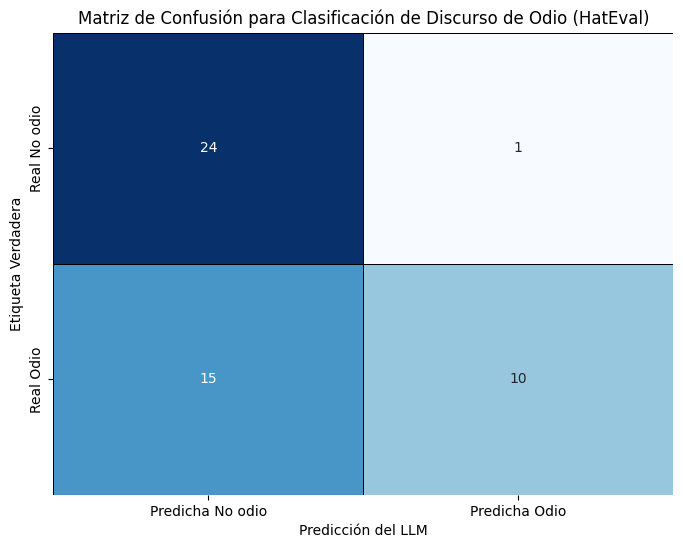

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtenemos las etiquetas verdaderas y predichas del DataFrame filtrado
y_true_filtered = filtered_rtas_test_df['hs_label']
y_pred_filtered = filtered_rtas_test_df['llm_label']

# Calculamos la matriz de confusión
cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=['No odio', 'Odio'])

# Creamos un DataFrame para la matriz de confusión con etiquetas claras
cm_df = pd.DataFrame(
    cm,
    index=['Real No odio', 'Real Odio'],
    columns=['Predicha No odio', 'Predicha Odio']
)

# Visualizamos la matriz de confusión con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='black')
plt.title('Matriz de Confusión para Clasificación de Discurso de Odio (HatEval)')
plt.xlabel('Predicción del LLM')
plt.ylabel('Etiqueta Verdadera')
plt.show()


Al analizar el `classification_report` y la matriz de confusión de arriba, conviene mirar dos cosas en particular:

- **El balance entre precisión y recall para la clase `Odio`**, y cómo se compara con los resultados de TF, TF-IDF y embeddings de la clase anterior (ver la tabla de conclusiones de `cap0/00 - SICSS-BAires - Vectorización.ipynb`): TF y TF-IDF empatan en F1 (0.665), por encima de embeddings (0.596).
- **Qué tipo de error predomina** en la matriz de confusión: si el LLM comete más falsos positivos (predice `Odio` cuando en realidad era `No odio`) o más falsos negativos (predice `No odio` cuando en realidad era `Odio`). Vamos a explorar ambos casos con ejemplos concretos en la siguiente sección.

## Análisis de errores
Un punto importante del trabajo con LLMs (y con cualquier modelo de clasificación de texto o no) es tratar de entender de alguna forma los errores que cometen.

Examinar las instancias mal clasificadas permite identificar patrones de error y comprender las limitaciones del modelo. Esto puede revelar sesgos en los datos de entrenamiento, características mal interpretadas o la necesidad de ajustes en el preprocesamiento del texto. Un análisis de errores riguroso proporciona información valiosa para refinar el modelo, mejorar su precisión y adaptarlo a casos de uso específicos.

Para ello vamos a realizar un análisis de casos individuales. Vamos a examinar manualmente los ejemplos mal clasificados para comprender por qué el modelo se equivocó. Puede revelar patrones de error específicos o problemas con el preprocesamiento del texto. Es útil para identificar sesgos en los datos de entrenamiento.

Veamos primero una muestra de 5 "falsos negativos":

In [ ]:
n_ejemplos = min(5, len(filtered_rtas_test_df[
    (filtered_rtas_test_df['hs_label'] == 'Odio') &
    (filtered_rtas_test_df['llm_label'] == 'No odio')
]))

false_negatives = filtered_rtas_test_df[
    (filtered_rtas_test_df['hs_label'] == 'Odio') &
    (filtered_rtas_test_df['llm_label'] == 'No odio')
][['text', 'llm_expl']].sample(n=n_ejemplos, random_state=42)

for index, row in false_negatives.iterrows():
  print("Tweet: " + str(index))
  print("\t" + "Texto: " + row['text'])
  print("\t" + "Explicación: " + row['llm_expl'] + "\n")


Tweet: 38
	Texto: «Cállate, puta vieja, o te rajo el cuello». Restos orgánicos, basura, amenazas a los vecinos. Aumentan los "narcopi… https://t.co/5f6FqHuAOO
	Explicación: El tweet reproduce una cita entrecomillada («Cállate, puta vieja, o te rajo el cuello») que contiene un insulto y una amenaza dirigida a una persona específica en un contexto de convivencia vecinal o delincuencia ("narcopisos"). No se observa que el tweet exprese odio, deshumanización o llamados a la violencia dirigidos contra las mujeres o los inmigrantes como grupo o colectivo. De acuerdo con las instrucciones, las citas de discursos ajenos o los insultos puntuales a una persona se clasifican como "No odio".

Tweet: 44
	Texto: @elmundoes A este le dejaba yo enganchado en las concertinas.
	Explicación: El tweet expresa un deseo de daño o violencia física ("dejar enganchado en las concertinas") dirigido a un individuo específico ("A este"), en singular, probablemente en respuesta a una noticia publicada por el medio

In [ ]:
n_ejemplos = min(5, len(filtered_rtas_test_df[
    (filtered_rtas_test_df['hs_label'] == 'No odio') &
    (filtered_rtas_test_df['llm_label'] == 'Odio')
]))

false_positives = filtered_rtas_test_df[
    (filtered_rtas_test_df['hs_label'] == 'No odio') &
    (filtered_rtas_test_df['llm_label'] == 'Odio')
][['text', 'llm_expl']].sample(n=n_ejemplos, random_state=42)

for index, row in false_positives.iterrows():
  print("Tweet: " + str(index))
  print("\t" + "Texto: " + row['text'])
  print("\t" + "Explicación: " + row['llm_expl'] + "\n")


Tweet: 19
	Texto: @AS_AGabilondo la esencia sudaca, que hermoso
	Explicación: El tweet utiliza la palabra "sudaca", que es un término xenófobo, despectivo y altamente ofensivo utilizado para referirse a las personas de origen sudamericano, quienes forman parte del colectivo de inmigrantes. Al hacer referencia a "la esencia sudaca", el emisor utiliza un insulto grupal para generalizar y etiquetar de forma peyorativa a este colectivo, lo cual se encuadra dentro de la definición de discurso de odio dirigido a inmigrantes.



Entre los falsos negativos, en 4 de los 5 casos (tweets 38, 44, 25, 31) el modelo aplica de forma literal el criterio "debe estar dirigido al grupo, no a un individuo" para descartar como No odio insultos o amenazas explícitamente misóginas o violentas ("puta vieja, te rajo el cuello", "dejarlo enganchado en las concertinas", "pinta de puta", "cállate ya puta") solo porque el destinatario es una persona puntual (una vecina, un usuario, Victoria Donda). Esto sugiere que la regla que el LLM está siguiendo, probablemente tomada literalmente del prompt, es más restrictiva que el criterio real de etiquetado del dataset, que sí suele considerar HS=1 cuando el lenguaje agresivo se apoya en un rasgo protegido (género), aunque el blanco sea una persona específica. Es un error sistemático de recall, no de comprensión del lenguaje: el modelo identifica correctamente la violencia/el insulto, pero lo descarta por una condición de "alcance grupal" mal calibrada.

El caso 46 ("la puta madre" como intensificador de admiración) es distinto: la explicación del LLM es lingüísticamente sólida (uso idiomático rioplatense, no ofensivo), así que este FN en particular probablemente refleje ruido en la etiqueta humana más que una falla del modelo.

El único FP de la muestra (tweet 19, "la esencia sudaca, que hermoso") muestra el problema inverso: el modelo dispara Odio apoyándose casi exclusivamente en la presencia de un término considerado xenófobo ("sudaca"), sin ponderar que el tono del tweet ("qué hermoso") es ambiguo o incluso admirativo/irónico. Es la misma fragilidad "gatillada por palabra clave" que vimos en los modelos lineales (TF/TF-IDF), solo que acá es más llamativa porque el LLM sí tiene la capacidad de razonar sobre contexto y en este caso no la usó a fondo.

## Actividad
* Comparar en esta muestra pequeña (50 casos) la performance de otro LLM con pysentimiento.¿Cuál funciona mejor? ¿El LLM se acerca, iguala o supera a esos modelos?
* Pensar cómo podrían reformular el `prompt` para hacerlo más preciso: por ejemplo, ¿ayuda incluir 1-2 ejemplos (few-shot) de tweets con y sin discurso de odio, especialmente casos límite como los que vimos en el análisis de errores?

In [ ]:
###